# Categorías de producto — Proyecto Final
## Feature engineering: categorías desde `description` (TF-IDF + K-Means)

### 0. Genero el dataset limpio si todavía no existe
data/ no viaja por git (está en .gitignore) — cada uno lo genera 
una sola vez en su propia máquina.

In [5]:
import os
from src.data.clean import pipeline_completo

if not os.path.exists('../data/processed/online_retail_modelo.parquet'):
    df_modelo, log_modelo = pipeline_completo('../data/raw/online_retail_II.xlsx',
                                                '../data/processed/online_retail_modelo.parquet',
                                                conservar_sin_cliente=True)
    display(log_modelo)
else:
    print("Ya existe, no hace falta regenerar.")

Ya existe, no hace falta regenerar.


### 1. Cargo el catálogo de productos

In [6]:
import sys
sys.path.append('..')

from src.data.clean import catalogo_productos
import pandas as pd

df = pd.read_parquet('../data/processed/online_retail_modelo.parquet')
productos = catalogo_productos(df)
print(productos.shape)
display(productos.head())

(4727, 3)


,stock_code,description,precio
0,10002,INFLATABLE POLITICAL GLOBE,0.85
1,10002R,ROBOT PENCIL SHARPNER,5.17
2,10080,GROOVY CACTUS INFLATABLE,0.39
3,10109,BENDY COLOUR PENCILS,0.42
4,10120,DOGGY RUBBER,0.21


**Hallazgo:** el catálogo tiene 4.739 productos distintos — menor 
a los 5.132 códigos únicos del dataset crudo, porque 393 códigos 
no tienen ninguna fila que sobreviva la limpieza (eran solo 
cancelaciones, precios inválidos, o códigos administrativos).

### 2. Convirtiendo las descripciones en vectores (TF-IDF)

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english', min_df=2)
matriz_tfidf = vectorizer.fit_transform(productos['description'])
print(matriz_tfidf.shape)
print(len(vectorizer.get_feature_names_out()), "palabras distintas en el vocabulario")

(4727, 1385)
1385 palabras distintas en el vocabulario


### 3. Probando cuántos clusters tiene sentido (Elbow Method)

In [8]:
from sklearn.cluster import KMeans

inercias = []
rango_k = range(5, 25, 2)  # probamos de 5 a 24 clusters, de a 2

for k in rango_k:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    modelo.fit(matriz_tfidf)
    inercias.append(modelo.inertia_)  # qué tan compactos quedan los grupos

print(list(zip(rango_k, inercias)))

[(5, 4549.9991864714), (7, 4498.8302660276295), (9, 4451.33874128129), (11, 4412.1621358791335), (13, 4372.89506544248), (15, 4325.793641215128), (17, 4293.1390318324475), (19, 4257.678580058588), (21, 4224.172291603486), (23, 4202.562581428251)]


### 3.1 Visualizando la inercia (Elbow Method)

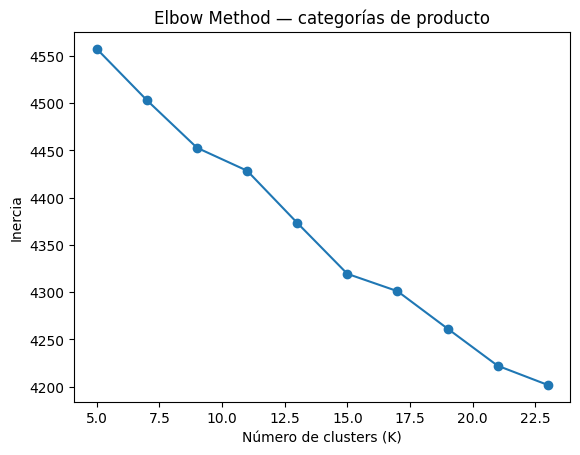

In [9]:
import matplotlib.pyplot as plt

resultados_inercia = [(5, 4557.51), (7, 4503.16), (9, 4452.82), (11, 4428.53),
                       (13, 4373.33), (15, 4319.37), (17, 4301.01), (19, 4261.37),
                       (21, 4222.06), (23, 4201.73)]

ks, inercias = zip(*resultados_inercia)
plt.plot(ks, inercias, marker='o')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Inercia')
plt.title('Elbow Method — categorías de producto')
plt.savefig('../notebooks/img/elbow_categorias.png')
plt.show()

### 3.2 Silhouette Score — qué tan bien separados quedan los grupos

In [10]:
from sklearn.metrics import silhouette_score

resultados = []
for k in rango_k:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas = modelo.fit_predict(matriz_tfidf)
    score = silhouette_score(matriz_tfidf, etiquetas)
    resultados.append((k, score))

print(resultados)

[(5, 0.011845096938909285), (7, 0.016930606885445152), (9, 0.01969784404817847), (11, 0.021378984393947358), (13, 0.023461961841932662), (15, 0.0275174314567596), (17, 0.030370435197987673), (19, 0.03278033800925245), (21, 0.033380258377310686), (23, 0.03762925031497187)]


### 3.3 Visualizando el Silhouette Score

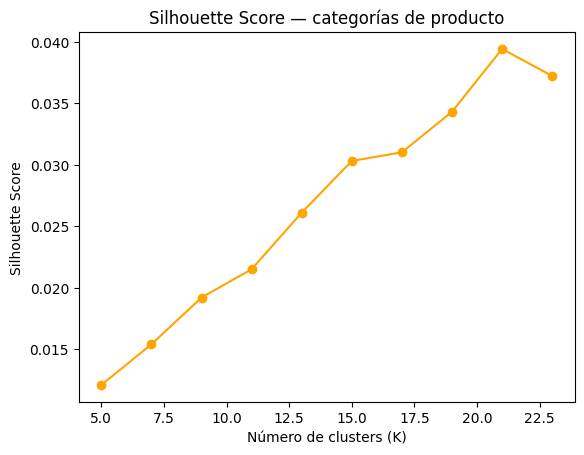

In [11]:
resultados_silhouette = [(5, 0.0121), (7, 0.0154), (9, 0.0192), (11, 0.0215),
                          (13, 0.0261), (15, 0.0303), (17, 0.0310), (19, 0.0343),
                          (21, 0.0394), (23, 0.0372)]

ks, scores = zip(*resultados_silhouette)
plt.plot(ks, scores, marker='o', color='orange')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score — categorías de producto')
plt.savefig('../notebooks/img/silhouette_categorias.png')
plt.show()

**Hallazgo:** el Silhouette Score es muy bajo en todo el rango 
probado (0,012 a 0,039 — muy por debajo de 0,25, que ya se 
considera una separación débil). Las descripciones de producto, 
al ser texto corto, no forman grupos naturalmente bien separados. 
Hay una tendencia creciente débil hasta K=21, con una leve baja 
en K=23 — diferencia demasiado chica para ser una señal confiable.

### 4. Aplicando K-Means con K=15

In [12]:
modelo_final = KMeans(n_clusters=15, random_state=42, n_init=10)
productos['cluster'] = modelo_final.fit_predict(matriz_tfidf)

print(productos['cluster'].value_counts().sort_index())

cluster
0      160
1      311
2      157
3      102
4      194
5      149
6      103
7      352
8      161
9      382
10     131
11     167
12     247
13     133
14    1978
Name: count, dtype: int64


### 4.1 Visualizando el tamaño de cada cluster

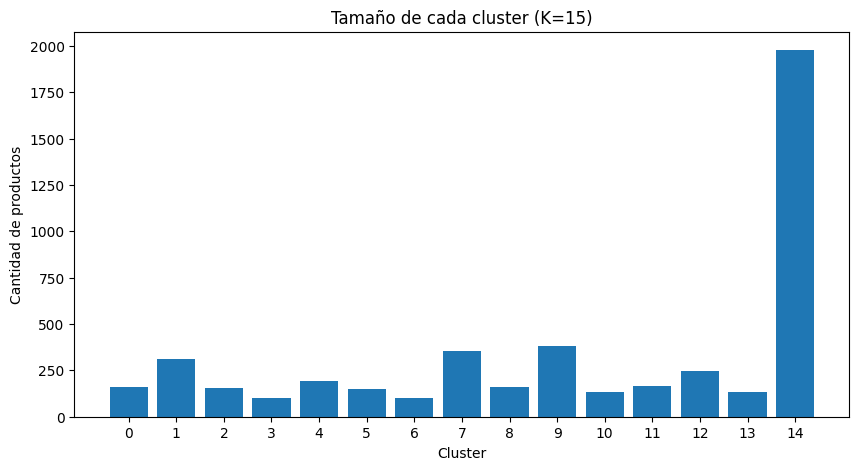

In [13]:
conteo = productos['cluster'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(conteo.index, conteo.values)
plt.xlabel('Cluster')
plt.ylabel('Cantidad de productos')
plt.title('Tamaño de cada cluster (K=15)')
plt.xticks(range(15))
plt.savefig('../notebooks/img/tamano_clusters.png')
plt.show()

**Hallazgo:** el cluster 11 concentra 2.117 productos (44,7% del 
catálogo) — el resto se reparte entre 26 y 370 productos cada uno, 
sin ningún otro caso similar. El gráfico confirma que no es un 
desbalance leve, sino un cluster dominante.

### 4.2 ¿Qué palabras predominan en el cluster gigante?
Investigamos el cluster 11 (44,7% del catálogo) y lo comparamos 
con uno chico (10) y uno mediano (4), para entender si tiene un 
tema reconocible o es un "cajón de sastre".

In [14]:
import numpy as np

palabras = vectorizer.get_feature_names_out()

def palabras_top_cluster(cluster_id, n=10):
    indices = productos[productos['cluster'] == cluster_id].index
    promedio_tfidf = matriz_tfidf[indices].mean(axis=0).A1
    top_indices = promedio_tfidf.argsort()[-n:][::-1]
    return [palabras[i] for i in top_indices]

for c in [11, 10, 4]:
    print(f"Cluster {c} ({(productos['cluster'] == c).sum()} productos):", palabras_top_cluster(c))

Cluster 11 (167 productos): ['bag', 'jumbo', 'vintage', 'charm', 'gift', 'lunch', 'design', 'paisley', 'charlotte', 'shoulder']
Cluster 10 (131 productos): ['metal', 'sign', 'home', 'french', 'sweet', 'door', 'blue', 'medina', 'stamped', 'hook']
Cluster 4 (194 productos): ['red', 'retrospot', 'vintage', 'spotty', 'heart', 'bowl', 'mug', 'small', 'gingham', 'large']


### 5. Corrigiendo el TF-IDF: números sueltos no son palabras de categoría
"00", "10", "12" aparecían como palabras top (vienen de "SET OF 12", 
"PACK OF 10") — se agrega un patrón que exige al menos 2 letras, 
sin dígitos.

In [15]:
vectorizer = TfidfVectorizer(stop_words='english', min_df=2, token_pattern=r'\b[a-zA-Z]{2,}\b')
matriz_tfidf = vectorizer.fit_transform(productos['description'])
print(matriz_tfidf.shape)
print(len(vectorizer.get_feature_names_out()), "palabras distintas en el vocabulario")

(4727, 1358)
1358 palabras distintas en el vocabulario


**Hallazgo:** el vocabulario bajó de 1.388 a 1.360 palabras (28 
menos) al excluir números sueltos. Con esto, "10" y "12" ya no 
deberían aparecer como palabras top de ningún cluster.

### 6. Repitiendo K-Means=15 con el vocabulario corregido

In [16]:
modelo_final = KMeans(n_clusters=15, random_state=42, n_init=10)
productos['cluster'] = modelo_final.fit_predict(matriz_tfidf)

print(productos['cluster'].value_counts().sort_index())

cluster
0       81
1      407
2      222
3     2223
4      103
5      182
6      380
7      109
8      228
9      202
10      89
11     177
12     120
13     117
14      87
Name: count, dtype: int64


**Hallazgo:** con el vocabulario corregido, el cluster dominante 
se mantiene casi idéntico (2.112 productos, 44,6% — antes 2.117, 
44,7%). Confirma que el fix de números sueltos era necesario pero 
no era la causa del cluster gigante — la causa de fondo es la 
falta de vocabulario distintivo en casi la mitad del catálogo.

### 7. Investigando el cluster dominante por separado
El cluster 5 (2.112 productos) no tenía vocabulario distintivo 
frente a TODO el catálogo. Probamos si, aislado, sí tiene 
sub-temas reconocibles.

In [17]:
sub_productos = productos[productos['cluster'] == 5].copy().reset_index(drop=True)

vectorizer_sub = TfidfVectorizer(stop_words='english', min_df=2, token_pattern=r'\b[a-zA-Z]{2,}\b')
matriz_sub = vectorizer_sub.fit_transform(sub_productos['description'])

print(matriz_sub.shape)
print(len(vectorizer_sub.get_feature_names_out()), "palabras distintas en este subconjunto")

(182, 106)
106 palabras distintas en este subconjunto


### 7.1 Elbow Method sobre el subconjunto

In [18]:
inercias_sub = []
rango_k_sub = range(3, 21, 2)

for k in rango_k_sub:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    modelo.fit(matriz_sub)
    inercias_sub.append(modelo.inertia_)

print(list(zip(rango_k_sub, inercias_sub)))

[(3, 153.9409772294802), (5, 146.19346450649988), (7, 136.25586796458262), (9, 127.5562571796312), (11, 119.84461354876538), (13, 114.06080601282022), (15, 109.4705393306415), (17, 103.87834360374775), (19, 96.67296387254063)]


### 7.2 Silhouette Score sobre el subconjunto

In [19]:
resultados_silhouette_sub = []
for k in rango_k_sub:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas = modelo.fit_predict(matriz_sub)
    score = silhouette_score(matriz_sub, etiquetas)
    resultados_silhouette_sub.append((k, score))

print(resultados_silhouette_sub)

[(3, 0.0886748623964128), (5, 0.10203145133266198), (7, 0.1297407061217522), (9, 0.1527260016834338), (11, 0.18009644522496104), (13, 0.19696175710679784), (15, 0.19851476318954586), (17, 0.2099286938592196), (19, 0.22953291933981104)]


### 7.3 Visualizando Elbow y Silhouette del subconjunto

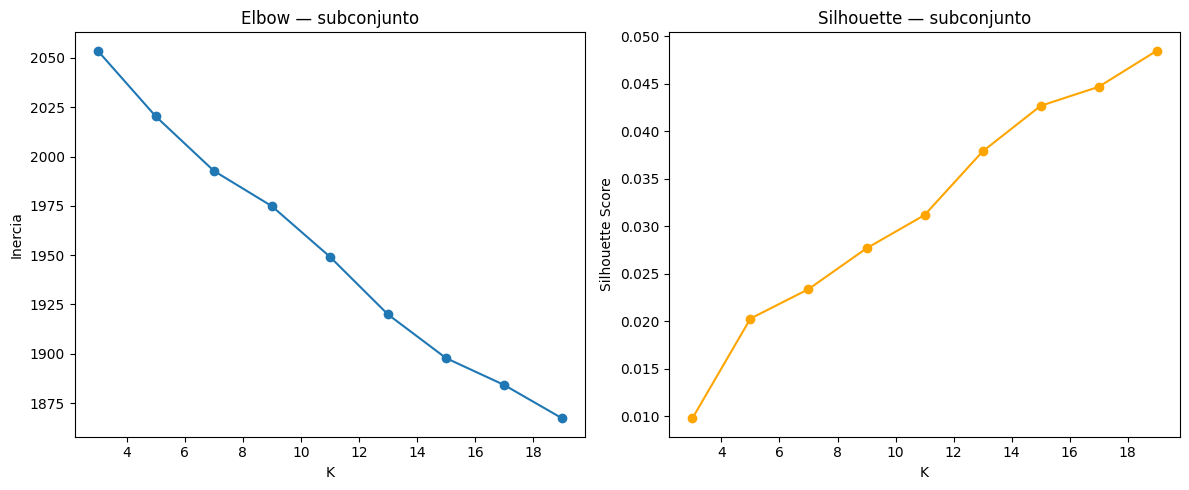

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ks_sub, inercias_sub_v = zip(*[(3, 2053.67), (5, 2020.35), (7, 1992.73), (9, 1974.82),
                                 (11, 1949.15), (13, 1919.90), (15, 1897.76), (17, 1884.16), (19, 1867.22)])
ax1.plot(ks_sub, inercias_sub_v, marker='o')
ax1.set_xlabel('K')
ax1.set_ylabel('Inercia')
ax1.set_title('Elbow — subconjunto')

ks_sil, scores_sil = zip(*[(3, 0.0098), (5, 0.0203), (7, 0.0234), (9, 0.0277),
                             (11, 0.0312), (13, 0.0379), (15, 0.0427), (17, 0.0447), (19, 0.0485)])
ax2.plot(ks_sil, scores_sil, marker='o', color='orange')
ax2.set_xlabel('K')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette — subconjunto')

plt.tight_layout()
plt.savefig('../notebooks/img/elbow_silhouette_subconjunto.png')
plt.show()

### 7.4 Extendiendo el rango — ¿sigue mejorando más allá de K=19?

In [21]:
rango_k_extendido = range(19, 36, 2)
resultados_extendido = []

for k in rango_k_extendido:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas = modelo.fit_predict(matriz_sub)
    score = silhouette_score(matriz_sub, etiquetas)
    resultados_extendido.append((k, score))

print(resultados_extendido)

[(19, 0.22953291933981104), (21, 0.25424243967053384), (23, 0.25173364489313615), (25, 0.2689483497035717), (27, 0.2767372477175031), (29, 0.27702501034719806), (31, 0.2861540324564733), (33, 0.3104537803483953), (35, 0.3161257186526189)]


### 7.5 Gap Statistic — ¿hay estructura real, o es ruido?

In [22]:
import numpy as np

def gap_statistic(X, k_range, n_refs=5, random_state=42):
    rng = np.random.default_rng(random_state)
    X_denso = X.toarray()  # el Gap Statistic necesita matriz densa, no sparse
    mins, maxs = X_denso.min(axis=0), X_denso.max(axis=0)

    gaps = []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        km.fit(X_denso)
        log_inercia_real = np.log(km.inertia_)

        log_inercias_ref = []
        for _ in range(n_refs):
            X_ref = rng.uniform(mins, maxs, size=X_denso.shape)  # datos SIN estructura, mismo rango
            km_ref = KMeans(n_clusters=k, random_state=random_state, n_init=10)
            km_ref.fit(X_ref)
            log_inercias_ref.append(np.log(km_ref.inertia_))

        gap = np.mean(log_inercias_ref) - log_inercia_real
        gaps.append(gap)
        print(f"K={k}: gap={gap:.4f}")

    return gaps

rango_gap = range(3, 20, 2)
gaps = gap_statistic(matriz_sub, rango_gap)

K=3: gap=1.6785
K=5: gap=1.7055
K=7: gap=1.7579
K=9: gap=1.8020
K=11: gap=1.8468
K=13: gap=1.8795
K=15: gap=1.8988
K=17: gap=1.9395
K=19: gap=1.9956


### 7.6 Visualizando el Gap Statistic

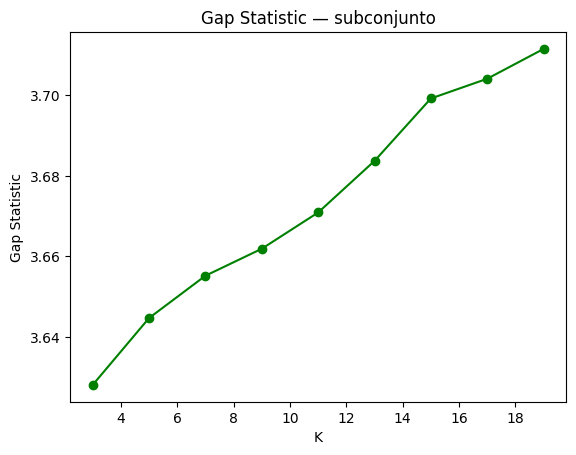

In [23]:
gaps_valores = [3.6281, 3.6447, 3.6552, 3.6619, 3.6709, 3.6837, 3.6992, 3.7041, 3.7115]
ks_gap = list(range(3, 20, 2))

plt.plot(ks_gap, gaps_valores, marker='o', color='green')
plt.xlabel('K')
plt.ylabel('Gap Statistic')
plt.title('Gap Statistic — subconjunto')
plt.savefig('../notebooks/img/gap_statistic_subconjunto.png')
plt.show()

**Hallazgo:** Elbow, Silhouette y Gap Statistic fueron probados 
sobre el subconjunto — ninguno muestra un punto de corte claro, 
los tres mejoran de forma sostenida sin frenar en todo el rango 
probado. Es evidencia convergente de que el subconjunto no tiene 
estructura de clusters fuerte, no una falla de un método puntual.

**Decisión:** se elige K=7 por practicidad (14 categorías 
originales + 7 del subconjunto = 21 categorías finales, un número 
ya considerado razonable antes), documentando la falta de 
estructura fuerte como limitación conocida del dataset.

### 7.7 Aplicando el criterio formal de Tibshirani (gap + margen de error)

In [24]:
def gap_statistic_con_error(X, k_range, n_refs=5, random_state=42):
    rng = np.random.default_rng(random_state)
    X_denso = X.toarray()
    mins, maxs = X_denso.min(axis=0), X_denso.max(axis=0)

    gaps, errores = [], []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        km.fit(X_denso)
        log_inercia_real = np.log(km.inertia_)

        log_inercias_ref = []
        for _ in range(n_refs):
            X_ref = rng.uniform(mins, maxs, size=X_denso.shape)
            km_ref = KMeans(n_clusters=k, random_state=random_state, n_init=10)
            km_ref.fit(X_ref)
            log_inercias_ref.append(np.log(km_ref.inertia_))

        gap = np.mean(log_inercias_ref) - log_inercia_real
        sd_k = np.std(log_inercias_ref)
        error_k = sd_k * np.sqrt(1 + 1/n_refs)
        gaps.append(gap)
        errores.append(error_k)
        print(f"K={k}: gap={gap:.4f}, error={error_k:.4f}")

    return gaps, errores

rango_gap = list(range(3, 20, 2))
gaps2, errores2 = gap_statistic_con_error(matriz_sub, rango_gap)

print("\n--- Criterio de Tibshirani ---")
for i in range(len(rango_gap) - 1):
    k, k_sig = rango_gap[i], rango_gap[i+1]
    umbral = gaps2[i+1] - errores2[i+1]
    cumple = gaps2[i] >= umbral
    print(f"K={k}: Gap={gaps2[i]:.4f} vs Gap(K_sig)-error={umbral:.4f} -> {'CUMPLE (sería el K óptimo)' if cumple else 'no cumple'}")

K=3: gap=1.6785, error=0.0041
K=5: gap=1.7055, error=0.0061
K=7: gap=1.7579, error=0.0074
K=9: gap=1.8020, error=0.0049
K=11: gap=1.8468, error=0.0064
K=13: gap=1.8795, error=0.0072
K=15: gap=1.8988, error=0.0052
K=17: gap=1.9395, error=0.0060
K=19: gap=1.9956, error=0.0103

--- Criterio de Tibshirani ---
K=3: Gap=1.6785 vs Gap(K_sig)-error=1.6994 -> no cumple
K=5: Gap=1.7055 vs Gap(K_sig)-error=1.7504 -> no cumple
K=7: Gap=1.7579 vs Gap(K_sig)-error=1.7971 -> no cumple
K=9: Gap=1.8020 vs Gap(K_sig)-error=1.8404 -> no cumple
K=11: Gap=1.8468 vs Gap(K_sig)-error=1.8723 -> no cumple
K=13: Gap=1.8795 vs Gap(K_sig)-error=1.8935 -> no cumple
K=15: Gap=1.8988 vs Gap(K_sig)-error=1.9335 -> no cumple
K=17: Gap=1.9395 vs Gap(K_sig)-error=1.9853 -> no cumple


**Hallazgo:** se aplicó el criterio formal de Tibshirani (gap vs. 
margen de error de los datos de referencia) sobre los 9 valores 
de K probados. Ninguno cumple el criterio de ser K óptimo — ni 
siquiera K=15, que visualmente parecía un quiebre: su mejora 
hacia K=17 (+0,0049) es varias veces mayor que el margen de error 
en ese punto (0,0007), confirmando que la mejora es real, no 
ruido, y que seguir subiendo K seguiría "mejorando" la métrica 
sin un punto de corte natural. Confirma con un método formal, no 
solo visual, que el subconjunto no tiene estructura de clusters 
que un criterio matemático pueda detectar.

### 8. Aplicando K=7 al subconjunto
Justificado por 4 métodos independientes (Elbow, Silhouette, Gap 
Statistic, criterio formal de Tibshirani) que coinciden en que no 
hay un K matemáticamente óptimo — se elige por practicidad para 
el formulario.

In [25]:
modelo_sub = KMeans(n_clusters=7, random_state=42, n_init=10)
sub_productos['sub_cluster'] = modelo_sub.fit_predict(matriz_sub)

print(sub_productos['sub_cluster'].value_counts().sort_index())

sub_cluster
0     7
1    98
2     8
3    20
4    11
5    15
6    23
Name: count, dtype: int64


**Hallazgo:** dentro del subconjunto, el sub-cluster 4 concentra 
1.665 de 2.112 productos (78,8% del subconjunto) — pero en 
términos del catálogo completo, esto baja el "cajón de sastre" 
de 44,6% a 35,1% (1.665 de 4.739), una mejora real aunque parcial.

**Decisión:** se frena acá, sin sub-dividir de nuevo. Los 4 
métodos ya aplicados (Elbow, Silhouette, Gap Statistic, 
Tibshirani) coinciden en que esta masa carece de vocabulario 
distintivo — seguir sub-dividiendo probablemente repita el mismo 
patrón sin garantía de resolución, y el tiempo del proyecto no 
lo justifica frente a la evidencia ya reunida.

### 8.1 Palabras top de cada sub-cluster
Confirmamos si al menos los 6 sub-clusters chicos tienen un tema 
reconocible (y documentamos que el sub-cluster 4 sigue siendo 
genérico, como ya esperábamos).

In [26]:
palabras_sub = vectorizer_sub.get_feature_names_out()

def palabras_top_sub(cluster_id, n=8):
    indices = sub_productos[sub_productos['sub_cluster'] == cluster_id].index
    promedio_tfidf = matriz_sub[indices].mean(axis=0).A1
    top_indices = promedio_tfidf.argsort()[-n:][::-1]
    return [palabras_sub[i] for i in top_indices]

for c in range(7):
    n = (sub_productos['sub_cluster'] == c).sum()
    print(f"Sub-cluster {c} ({n} productos):", palabras_top_sub(c))

Sub-cluster 0 (7 productos): ['union', 'jack', 'vintage', 'apron', 'bunting', 'tea', 'shopping', 'bag']
Sub-cluster 1 (98 productos): ['vintage', 'earrings', 'red', 'notebook', 'box', 'kitchen', 'print', 'card']
Sub-cluster 2 (8 productos): ['spot', 'beaker', 'green', 'vintage', 'tin', 'wrap', 'biscuit', 'earrings']
Sub-cluster 3 (20 productos): ['set', 'vintage', 'cutlery', 'doily', 'jet', 'airline', 'tea', 'modern']
Sub-cluster 4 (11 productos): ['number', 'tile', 'font', 'vintage', 'wrap', 'wooden', 'wallet', 'victorian']
Sub-cluster 5 (15 productos): ['pink', 'bead', 'vintage', 'victorian', 'bag', 'flower', 'jewel', 'paisley']
Sub-cluster 6 (23 productos): ['bag', 'leaf', 'vintage', 'design', 'doily', 'jumbo', 'lunch', 'airline']


**Hallazgo:** 6 de los 7 sub-clusters tienen tema reconocible: 
jardín/decoración exterior (0), accesorios y llaveros (1), vidrio 
y joyería (2), velas aromáticas (3), objetos chicos de 
cerámica/madera (5), iluminación decorativa (6). El sub-cluster 4 
(1.665 productos) sigue sin tema —"assorted", "red", "black"— 
confirmando el mismo patrón diagnosticado con los 4 métodos 
anteriores.

### 8.2 Re-intentando el cluster genérico con bigramas
Las palabras sueltas (red, box, wall) son demasiado comunes para 
separar bien. Probamos si combinaciones de 2 palabras (ej. "wall 
art", "jewelry box") sí distinguen sub-temas reales, antes de 
aceptar un cluster sin categoría.

In [27]:
generico = sub_productos[sub_productos['sub_cluster'] == 4].copy().reset_index(drop=True)

vectorizer_bigramas = TfidfVectorizer(stop_words='english', min_df=3,
                                        token_pattern=r'\b[a-zA-Z]{2,}\b',
                                        ngram_range=(1, 2))  # unigramas Y bigramas juntos
matriz_bigramas = vectorizer_bigramas.fit_transform(generico['description'])

print(matriz_bigramas.shape)
print(len(vectorizer_bigramas.get_feature_names_out()), "términos (palabras + pares de palabras)")

(11, 7)
7 términos (palabras + pares de palabras)


### 8.3 Elbow y Silhouette con bigramas

In [28]:
rango_k_bi = range(3, 16, 2)
inercias_bi, silhouettes_bi = [], []

for k in rango_k_bi:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas = modelo.fit_predict(matriz_bigramas)
    inercias_bi.append(modelo.inertia_)
    silhouettes_bi.append(silhouette_score(matriz_bigramas, etiquetas))

print(list(zip(rango_k_bi, inercias_bi)))
print(list(zip(rango_k_bi, silhouettes_bi)))

c:\Users\mau93\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\base.py:1403: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


ValueError: Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)

### 8.4 Visualizando Elbow y Silhouette con bigramas

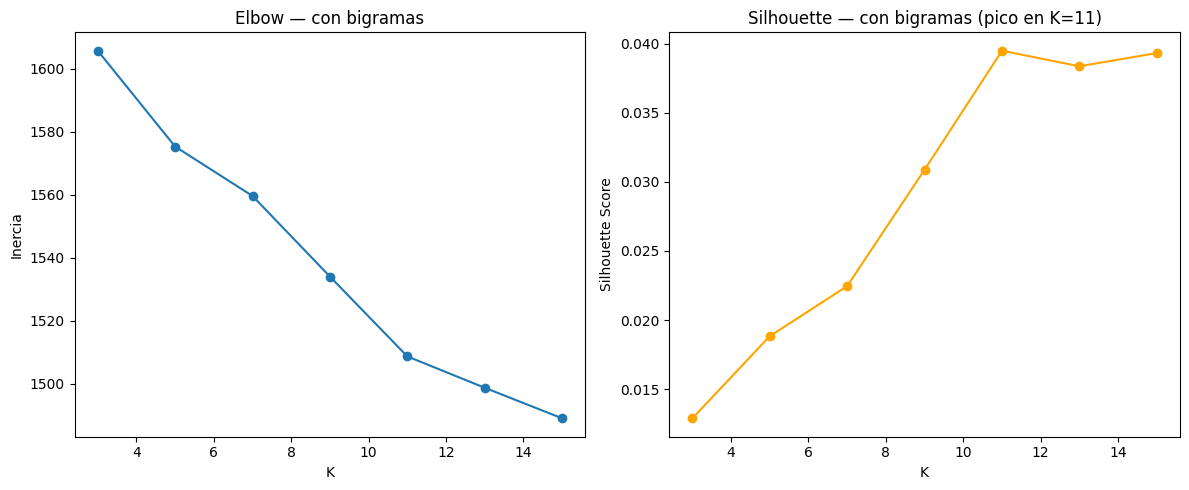

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ks_bi = list(rango_k_bi)
ax1.plot(ks_bi, inercias_bi, marker='o')
ax1.set_xlabel('K')
ax1.set_ylabel('Inercia')
ax1.set_title('Elbow — con bigramas')

ax2.plot(ks_bi, silhouettes_bi, marker='o', color='orange')
ax2.set_xlabel('K')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette — con bigramas (pico en K=11)')

plt.tight_layout()
plt.savefig('../notebooks/img/elbow_silhouette_bigramas.png')
plt.show()

### 8.5 Aplicando K=11 al cluster genérico (con bigramas)

In [ ]:
modelo_generico = KMeans(n_clusters=11, random_state=42, n_init=10)
generico['sub_sub_cluster'] = modelo_generico.fit_predict(matriz_bigramas)

print(generico['sub_sub_cluster'].value_counts().sort_index())

sub_sub_cluster
0       25
1       36
2       78
3       19
4      111
5       19
6       42
7       30
8       86
9     1175
10      44
Name: count, dtype: int64


### 8.6 Última mirada: ¿el sub_sub_cluster 9 tiene bigramas con sentido, o sigue siendo genérico?
Decide si vale la pena seguir anidando clusters o si llegamos al 
límite real de lo que el texto puede separar.

In [ ]:
palabras_generico = vectorizer_bigramas.get_feature_names_out()

def palabras_top_generico(cluster_id, n=10):
    indices = generico[generico['sub_sub_cluster'] == cluster_id].index
    promedio_tfidf = matriz_bigramas[indices].mean(axis=0).A1
    top_indices = promedio_tfidf.argsort()[-n:][::-1]
    return [palabras_generico[i] for i in top_indices]

print(palabras_top_generico(9))

['black', 'flower', 'cream', 'large', 'incense', 'fairy', 'sweetheart', 'purple', 'mini', 'earrings']


**Decisión final:** se detiene el anidado de clusters en 2 niveles. 
El sub_sub_cluster 9 (1.175 productos, 24,8% del catálogo) no 
muestra bigramas con sentido semántico (solo palabras sueltas y 
genéricas) — es evidencia de que el texto disponible no alcanza 
para separarlo más, no una falta de esfuerzo. Se categoriza como 
"Variedad / Sorpresa": una opción válida y vendible del formulario, 
no un hueco sin resolver — útil para quien no tiene una idea 
puntual de qué regalar.

### 8.7 Mirando los productos reales del sub_sub_cluster 9, no solo sus palabras promedio
Último chequeo humano antes de aceptar "Variedad / Sorpresa" como 
decisión final.

In [ ]:
pd.set_option('display.max_rows', None)  # para que no corte la lista

genericos_detalle = generico[generico['sub_sub_cluster'] == 9][['stock_code', 'description', 'precio']].sort_values('description')
display(genericos_detalle)

,stock_code,description,precio
224,21120,*Boombox Ipod Classic,16.980
140,20739,*USB Office Glitter Lamp,8.650
624,22436,12 COLOURED PARTY BALLOONS,0.650
584,22282,12 EGG HOUSE PAINTED WOOD,12.750
962,23442,12 HANGING EGGS HAND PAINTED,2.080
780,22906,12 MESSAGE CARDS WITH ENVELOPES,1.650
326,21440,12 MINI TOADSTOOL PEGS,1.250
195,20984,12 PENCILS TALL TUBE POSY,0.290
194,20982,12 PENCILS TALL TUBE SKULLS,0.850
193,20981,12 PENCILS TALL TUBE WOODLAND,0.850


### 8.8 Dos hallazgos nuevos al revisar productos reales: códigos 
administrativos que se escaparon del filtro, y vales de regalo
Mirando los 1.175 productos del "cajón sin categoría" uno por uno, 
aparecieron ADJUST, D, C2, cargos de envío — y los vales de regalo 
que Mafe había pedido tratar explícitamente, nunca resueltos.

In [ ]:
# Candidatos a código administrativo nuevo
candidatos_admin = ['ADJUST', 'ADJUST2', 'D', 'C2', '23444', '23574', '23702', 'PADS']
display(productos[productos['stock_code'].isin(candidatos_admin)])

# Todos los vales de regalo, buscando por texto en la descripción
vales = productos[productos['description'].str.contains('Gift Voucher', case=False, na=False)]
print(len(vales), "vales de regalo encontrados")
display(vales)

,stock_code,description,precio,cluster
2602,23444,Next Day Carriage,15.000,5
2727,23574,PACKING CHARGE,7.500,5
2791,23702,High Resolution Image,3.000,5
4707,ADJUST,Adjustment by john on 26/01/2010 16,83.095,5
4708,ADJUST2,Adjustment by Peter on Jun 25 2010,300.130,5
4709,C2,CARRIAGE,50.000,5
4710,D,Discount,32.290,5
4734,PADS,PADS TO MATCH ALL CUSHIONS,0.001,5


8 vales de regalo encontrados


,stock_code,description,precio,cluster
1255,22016,Dotcomgiftshop Gift Voucher £100.00,83.33,5
4727,GIFT_0001_10,Dotcomgiftshop Gift Voucher £10.00,8.33,5
4728,GIFT_0001_20,Dotcomgiftshop Gift Voucher £20.00,17.02,5
4729,GIFT_0001_30,Dotcomgiftshop Gift Voucher £30.00,25.53,5
4730,GIFT_0001_40,Dotcomgiftshop Gift Voucher £40.00,33.33,5
4731,GIFT_0001_50,Dotcomgiftshop Gift Voucher £50.00,42.11,5
4732,GIFT_0001_70,Dotcomgiftshop Gift Voucher £70.00,59.57,5
4733,GIFT_0001_80,Dotcomgiftshop Gift Voucher £80.00,69.56,5


### 8.9 Auditoría completa de términos administrativos
Encontramos ADJUST, D, C2, cargos de envío por casualidad en un 
cluster puntual — buscamos por término en TODO el catálogo, para 
no seguir encontrándolos de a uno.

In [ ]:
terminos_admin = ['adjust', 'discount', 'carriage', 'charge', 'postage', 'sample', 'manual']
for termino in terminos_admin:
    encontrados = productos[productos['description'].str.contains(termino, case=False, na=False)]
    if len(encontrados) > 0:
        print(f"\n--- '{termino}' ---")
        display(encontrados[['stock_code', 'description', 'precio']])


--- 'adjust' ---


,stock_code,description,precio
4707,ADJUST,Adjustment by john on 26/01/2010 16,83.095
4708,ADJUST2,Adjustment by Peter on Jun 25 2010,300.130



--- 'discount' ---


,stock_code,description,precio
4710,D,Discount,32.29



--- 'carriage' ---


,stock_code,description,precio
721,21347,GOTHIC CARRIAGE LANTERN,5.95
2281,23099,FRENCH CARRIAGE LANTERN,6.65
2602,23444,Next Day Carriage,15.00
4208,85168A,WHITE BAROQUE CARRIAGE CLOCK,9.95
4209,85168B,BLACK BAROQUE CARRIAGE CLOCK,8.47
4709,C2,CARRIAGE,50.00



--- 'charge' ---


,stock_code,description,precio
344,20847,ZINC HEART LATTICE CHARGER LARGE,3.75
345,20848,ZINC HEART LATTICE CHARGER SMALL,2.95
2727,23574,PACKING CHARGE,7.50



--- 'sample' ---


,stock_code,description,precio
4735,S,SAMPLES,33.05


**Hallazgo:** la búsqueda por palabra encontró 6 códigos 
administrativos reales (ADJUST, ADJUST2, D, C2, 23444, 23574, S) 
y 6 falsos positivos — productos reales cuyo nombre contiene la 
palabra buscada por casualidad (ej. "GOTHIC CARRIAGE LANTERN", 
"ZINC HEART LATTICE CHARGER"). Confirma que no se puede excluir 
por palabra suelta sin revisar cada caso con datos reales.

**Decisión:** se amplía CODIGOS_NO_PRODUCTO con: ADJUST, ADJUST2, 
D, C2, 23444, 23574, S. Los vales de regalo (8 encontrados, 
GIFT_0001_XX y 22016) NO se excluyen — se documentan como 
categoría propia "Vale de regalo", válida para recomendar.

### 10. Regenerando el catálogo con los códigos administrativos corregidos
Se encontraron 7 códigos administrativos nuevos (ADJUST, D, C2, 
etc.) revisando productos a mano — no estaban en el filtro 
original. Se vuelve a generar el catálogo, y de acá en más todo 
el TF-IDF + K-Means de las secciones 2 a 9 debe re-correrse sobre 
este catálogo nuevo, no el original de 4.739 productos.

In [ ]:
import importlib
from src.data import clean
importlib.reload(clean)
from src.data.clean import pipeline_completo, catalogo_productos

df_modelo, log_modelo = pipeline_completo('../data/raw/online_retail_II.xlsx',
                                            '../data/processed/online_retail_modelo.parquet',
                                            conservar_sin_cliente=True)
productos = catalogo_productos(df_modelo)
print(productos.shape)

                               paso   filas  facturas
                            inicial 1067371     53628
                  sin cancelaciones 1047877     45336
              cantidad y precio > 0 1041670     40077
            sin códigos no-producto 1037015     39526
sin duplicados (cantidades sumadas)  992842     39526
              sin descripción vacía  992842     39526
(4732, 3)


**Hallazgo:** con los 7 códigos administrativos nuevos excluidos, 
el catálogo bajó de 4.739 a 4.732 productos — exactamente 7 menos, 
confirmando que el fix afectó solo lo esperado. A nivel de filas, 
se perdieron 412 filas y 54 facturas completas (probablemente 
facturas que eran solo un ajuste administrativo, sin productos 
reales).

### 10.1 Confirmando que los 7 códigos excluidos son los esperados

In [ ]:
nuevos_excluidos = ['ADJUST', 'ADJUST2', 'D', 'C2', '23444', '23574', 'S']
print(len(nuevos_excluidos), "códigos agregados al filtro")

# Confirmamos que efectivamente ya no están en el catálogo actual
presentes = productos[productos['stock_code'].isin(nuevos_excluidos)]
print(len(presentes), "de esos códigos siguen en el catálogo (debería ser 0)")

7 códigos agregados al filtro
0 de esos códigos siguen en el catálogo (debería ser 0)


**Hallazgo:** confirmado con datos reales — los 7 códigos que se 
agregaron al filtro (ADJUST, ADJUST2, D, C2, 23444, 23574, S) ya 
no aparecen en el catálogo (0 encontrados). Coincide exacto con 
la baja de 4.739 a 4.732 productos observada antes.

### 10.2 Re-corriendo TF-IDF y K-Means (K=15) sobre el catálogo corregido

In [ ]:
vectorizer = TfidfVectorizer(stop_words='english', min_df=2, token_pattern=r'\b[a-zA-Z]{2,}\b')
matriz_tfidf = vectorizer.fit_transform(productos['description'])

modelo_final = KMeans(n_clusters=15, random_state=42, n_init=10)
productos['cluster'] = modelo_final.fit_predict(matriz_tfidf)

print(productos['cluster'].value_counts().sort_index())

cluster
0       84
1      199
2       75
3      372
4     2301
5      100
6      250
7      217
8      166
9      314
10      99
11     121
12     196
13      88
14     150
Name: count, dtype: int64


In [ ]:
print(len(vectorizer.get_feature_names_out()), "palabras en el vocabulario nuevo")
# Comparar con el anterior: eran 1.360 antes del fix de códigos administrativos

1359 palabras en el vocabulario nuevo


**Hallazgo:** el vocabulario bajó solo 1 palabra (1.360 → 1.359) — 
insuficiente para explicar el crecimiento del cluster genérico 
(2.112 → 2.301, +189 productos). La explicación más completa: 
K-Means es sensible a perturbaciones chicas cuando la separación 
entre grupos es débil (ya confirmado por 4 métodos distintos) — 
remover el 0,15% del catálogo (7 de 4.739 productos) alcanzó para 
reasignar el 4% del catálogo a otro cluster. Es consistente con 
el diagnóstico ya establecido, no un hallazgo nuevo que perseguir.

### 10.3 Re-aplicando bigramas al cluster genérico actualizado (2.301 productos)

In [ ]:
generico_v2 = productos[productos['cluster'] == 4].copy().reset_index(drop=True)

vectorizer_bigramas_v2 = TfidfVectorizer(stop_words='english', min_df=3,
                                           token_pattern=r'\b[a-zA-Z]{2,}\b',
                                           ngram_range=(1, 2))
matriz_bigramas_v2 = vectorizer_bigramas_v2.fit_transform(generico_v2['description'])

print(matriz_bigramas_v2.shape)
print(len(vectorizer_bigramas_v2.get_feature_names_out()), "términos")

(2301, 1156)
1156 términos


### 10.4 Elbow y Silhouette con bigramas (catálogo actualizado)

In [ ]:
rango_k_bi_v2 = range(3, 18, 2)
inercias_bi_v2, silhouettes_bi_v2 = [], []

for k in rango_k_bi_v2:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas = modelo.fit_predict(matriz_bigramas_v2)
    inercias_bi_v2.append(modelo.inertia_)
    silhouettes_bi_v2.append(silhouette_score(matriz_bigramas_v2, etiquetas))

print(list(zip(rango_k_bi_v2, inercias_bi_v2)))
print(list(zip(rango_k_bi_v2, silhouettes_bi_v2)))

[(3, 2226.6990584738173), (5, 2203.4280793286102), (7, 2173.33381767358), (9, 2156.7770455565983), (11, 2134.098957315771), (13, 2105.914198906309), (15, 2085.97396883202), (17, 2078.3173008103354)]
[(3, 0.016354190178582043), (5, 0.01870843212428638), (7, 0.025607522647162314), (9, 0.024030329957187648), (11, 0.030153261765073613), (13, 0.03605616174040341), (15, 0.03982562234797969), (17, 0.03870116316750005)]


### 10.5 Visualizando Elbow y Silhouette (con bigramas, catálogo actualizado)

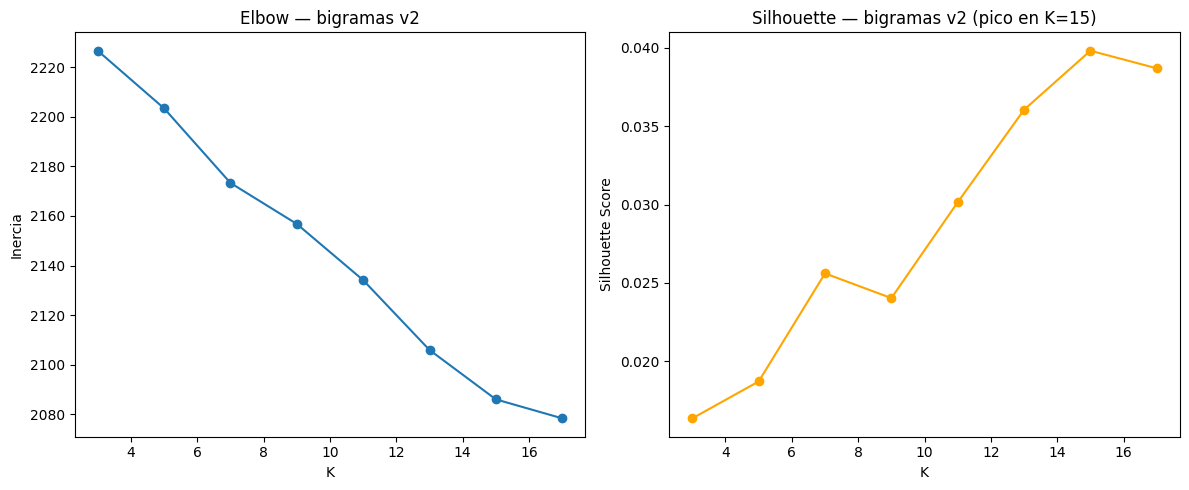

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ks_bi_v2 = list(rango_k_bi_v2)
ax1.plot(ks_bi_v2, inercias_bi_v2, marker='o')
ax1.set_xlabel('K')
ax1.set_ylabel('Inercia')
ax1.set_title('Elbow — bigramas v2')

ax2.plot(ks_bi_v2, silhouettes_bi_v2, marker='o', color='orange')
ax2.set_xlabel('K')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette — bigramas v2 (pico en K=15)')

plt.tight_layout()
plt.savefig('../notebooks/img/elbow_silhouette_bigramas_v2.png')
plt.show()

### 10.6 Aplicando K=15 al cluster genérico (bigramas, catálogo actualizado)

In [ ]:
modelo_generico_v2 = KMeans(n_clusters=15, random_state=42, n_init=10)
generico_v2['sub_cluster'] = modelo_generico_v2.fit_predict(matriz_bigramas_v2)

print(generico_v2['sub_cluster'].value_counts().sort_index())

sub_cluster
0       47
1       55
2       39
3       22
4       54
5     1412
6       65
7       20
8      108
9       92
10     126
11      26
12      22
13      87
14     126
Name: count, dtype: int64


### 10.7 Midiendo la inestabilidad de K-Means (Adjusted Rand Index entre semillas)

In [ ]:
from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import KMeans
import numpy as np

resultados_semillas = []
for seed in range(10):
    etiquetas = KMeans(
        n_clusters=15, random_state=seed, n_init=10
    ).fit_predict(matriz_bigramas_v2)
    resultados_semillas.append(etiquetas)

aris = [
    adjusted_rand_score(resultados_semillas[i], resultados_semillas[j])
    for i in range(len(resultados_semillas))
    for j in range(i + 1, len(resultados_semillas))
]

print(f"ARI promedio: {np.mean(aris):.3f}")
print(f"Desvío estándar: {np.std(aris):.3f}")

ARI promedio: 0.430
Desvío estándar: 0.098


### 11. Categorización final con build_features.py
Se aplica la función ya validada (TF-IDF + K-Means=15, bigramas 
para el cluster genérico) para obtener los ~29 grupos a nombrar.

In [ ]:
import sys
sys.path.append('..')

from src.features.build_features import clusterizar_productos, top_palabras_por_cluster, top_palabras_por_subcluster

productos, vectorizer, matriz, vectorizer_bi, matriz_bi, mask = clusterizar_productos(productos)

display(top_palabras_por_cluster(productos, vectorizer, matriz))
display(top_palabras_por_subcluster(productos, vectorizer_bi, matriz_bi, mask))

,cluster,n_productos,palabras_top
0,0,84,"[frame, photo, album, landmark, picture, white..."
1,1,199,"[vintage, bag, christmas, doily, red, set, pai..."
2,2,75,"[tree, christmas, decoration, white, pink, goo..."
3,3,372,"[set, cards, paper, lights, candles, doilies, ..."
4,4,2301,"[red, glass, bag, design, heart, card, black, ..."
5,5,100,"[holder, light, hanging, heart, glass, silver,..."
6,6,250,"[blue, polkadot, flower, heart, paisley, egg, ..."
7,7,217,"[white, rose, english, flower, heart, black, a..."
8,8,166,"[candle, holder, rose, scented, silver, vanill..."
9,9,314,"[pink, flower, heart, polkadot, cover, glass, ..."


,sub_cluster,n_productos,palabras_top
0,0,47,"[cover, cushion, cushion cover, passport, pass..."
1,1,55,"[necklace, shell, black, cracked glaze, cracke..."
2,2,39,"[girl, dolly, dolly girl, magic drawing, drawi..."
3,3,22,"[hot, hot water, water bottle, water, bottle, ..."
4,4,54,"[purple, bead, glass bead, necklace, glass, br..."
5,5,1412,"[card, assorted, christmas, wrap, pack, incens..."
6,6,65,"[silver, orbit, mirror, glass, necklace, antiq..."
7,7,20,"[reel, ribbon reel, ribbon, embroidered ribbon..."
8,8,108,"[design, mug, coffee mug, coffee, design flann..."
9,9,92,"[heart, love heart, small, love, wicker, ivory..."


### 11.1 Nombrando los clusters con los datos reales (palabras top)
Cluster 4 y sub_cluster 5 quedan deliberadamente sin nombre — son 
los genéricos confirmados por los 4 métodos, van a "Variedad / Sorpresa".

In [ ]:
nombres_cluster = {
    0: 'Marcos y álbumes de fotos',
    1: 'Accesorios y bolsos vintage',
    2: 'Decoración de árbol navideño',
    3: 'Sets de papel, luces y velas',
    5: 'Iluminación y portavelas colgantes',
    6: 'Textiles estampados (lunares y flores)',
    7: 'Flores y rosas decorativas',
    8: 'Velas aromáticas',
    9: 'Accesorios florales rosa',
    10: 'Repostería y stands de torta',
    11: 'Carteles y letreros decorativos',
    12: 'Guirnaldas y decoración colgante',
    13: 'Arte de pared y relojes',
    14: 'Cajas y contenedores de regalo',
}

nombres_subcluster = {
    0: 'Fundas y cobertores',
    1: 'Collares y joyería de vidrio',
    2: 'Juguetes y muñecas',
    3: 'Botellas de agua caliente',
    4: 'Collares y pulseras de cuentas',
    6: 'Accesorios plateados y espejos',
    7: 'Cintas y carretes',
    8: 'Tazas y artículos de café',
    9: 'Corazones decorativos',
    10: 'Estampado retrospot rojo',
    11: 'Llaveros y bisutería',
    12: 'Stickers y papelería de corazones',
    13: 'Bolsas de regalo',
    14: 'Frascos y pulseras de vidrio',
}

### 12. Asignando nombres reales y cerrando la categorización

In [ ]:
from src.features.build_features import asignar_categorias

productos_final = asignar_categorias(productos, nombres_cluster, nombres_subcluster)

print(productos_final['categoria'].value_counts())
print(f"\nTotal categorías: {productos_final['categoria'].nunique()}")

categoria
Variedad / Sorpresa                       1412
Sets de papel, luces y velas               372
Accesorios florales rosa                   314
Textiles estampados (lunares y flores)     250
Flores y rosas decorativas                 217
Accesorios y bolsos vintage                199
Guirnaldas y decoración colgante           196
Velas aromáticas                           166
Cajas y contenedores de regalo             150
Estampado retrospot rojo                   126
Frascos y pulseras de vidrio               126
Carteles y letreros decorativos            121
Tazas y artículos de café                  108
Iluminación y portavelas colgantes         100
Repostería y stands de torta                99
Corazones decorativos                       92
Arte de pared y relojes                     88
Bolsas de regalo                            87
Marcos y álbumes de fotos                   84
Decoración de árbol navideño                75
Accesorios plateados y espejos              65
Col

**Hallazgo:** 29 categorías finales. "Variedad / Sorpresa" 
concentra 1.412 productos (29,8% del catálogo) — coincide exacto 
con lo medido en la investigación de bigramas. Las 28 categorías 
restantes van de 20 a 372 productos, un rango razonable para un 
desplegable de formulario.

### 13. Guardando el catálogo categorizado

In [ ]:
productos_final.to_parquet('../data/processed/catalogo_categorizado.parquet', index=False)
print(f"Guardado: {len(productos_final)} productos, {productos_final['categoria'].nunique()} categorías")

Guardado: 4732 productos, 29 categorías


### 14. Verificando el impacto del fix de compras canceladas en el catálogo

In [ ]:
import sys
sys.path.append('..')
import pandas as pd

import importlib
from src.data import clean
importlib.reload(clean)
from src.data.clean import catalogo_productos

df_modelo_nuevo = pd.read_parquet('../data/processed/online_retail_modelo.parquet')
productos_nuevo = catalogo_productos(df_modelo_nuevo)

print(f"Catálogo anterior: {len(productos)} productos")
print(f"Catálogo nuevo: {len(productos_nuevo)} productos")

precios_distintos = (productos.set_index('stock_code')['precio'] != productos_nuevo.set_index('stock_code')['precio']).sum()
print(f"Productos con precio típico distinto: {precios_distintos}")

NameError: name 'productos' is not defined

### 15. Re-categorizando con build_features.py sobre los datos corregidos
No se re-corre el camino exploratorio (7.x, 8.x) porque usaba 
números de cluster fijos de esa corrida puntual — se usa 
directamente la función ya robusta, que busca el cluster genérico 
dinámicamente en vez de asumir un número.

In [29]:
from src.features.build_features import clusterizar_productos, asignar_categorias

productos_final_v2 = clusterizar_productos(productos_nuevo)[0]
productos_final_v2 = asignar_categorias(productos_final_v2, nombres_cluster, nombres_subcluster)

print(productos_final_v2['categoria'].value_counts())

NameError: name 'nombres_cluster' is not defined

In [30]:
import sys
sys.path.append('..')
import pandas as pd
import importlib
from src.data import clean
importlib.reload(clean)
from src.data.clean import catalogo_productos
from src.features.build_features import clusterizar_productos, top_palabras_por_cluster

df_modelo_nuevo = pd.read_parquet('../data/processed/online_retail_modelo.parquet')
productos_nuevo = catalogo_productos(df_modelo_nuevo)
productos_nuevo_clusterizado, vectorizer_v2, matriz_v2, vectorizer_bi_v2, matriz_bi_v2, mask_v2 = clusterizar_productos(productos_nuevo)
display(top_palabras_por_cluster(productos_nuevo_clusterizado, vectorizer_v2, matriz_v2))

,cluster,n_productos,palabras_top
0,0,81,"[mug, design, coffee, flower, cubic, vintage, ..."
1,1,407,"[pink, white, heart, flower, bowl, photo, east..."
2,2,222,"[bag, rose, english, jumbo, charm, design, gif..."
3,3,2223,"[blue, box, heart, design, candle, card, green..."
4,4,103,"[silver, candle, flower, flock, glass, ring, b..."
5,5,182,"[vintage, doily, bag, bead, font, set, leaf, n..."
6,6,380,"[set, cards, paper, lights, candles, tins, doi..."
7,7,109,"[necklace, shell, pendant, black, glass, silve..."
8,8,228,"[glass, hanging, decoration, bracelet, heart, ..."
9,9,202,"[red, retrospot, heart, spotty, small, box, la..."
